# COL Transect Maps 2024

In [2]:
#install.packages("plyr")
#install.packages("tidyverse")
#install.packages("reshape2")
#install.packages("ggplot2")
#install.packages("RColorBrewer")
#install.packages("stringr")
#install.packages("nloptr")
#install.packages("car")
#install.packages("ggmap")
#install.packages("sp")
#install.packages("ggrepel")


In [3]:
library(nlme)
library(plyr)
#library(car)
library(tidyverse)
library(reshape2) 
library(ggmap)
library(sp)
library(ggrepel)
library(ggplot2)
library(RColorBrewer)

In [4]:
getwd()

[1] "/Users/brookesienkiewicz/Documents/sctld/COL2024"

In [5]:
#setwd("Documents/sctld/SCTLD_samples/Sample_Data")
#setwd('Sample_Data')

In [6]:
list.files()

[1] "COL_maps.ipynb"                              
 [2] "COL_SAN_032024Nuts_tags.docx"                
 [3] "ELARBOL_color.tif"                           
 [4] "NIRVANA_color.tif"                           
 [5] "P3050030.MOV"                                
 [6] "P3050052.MOV"                                
 [7] "P3050107 (1).MOV"                            
 [8] "P3060037.JPG"                                
 [9] "P3061275.JPG"                                
[10] "PLAZADETOROS_color.tif"                      
[11] "Probiotics _excel_COL_SanAndres_03_2024.csv" 
[12] "Probiotics _excel_COL_SanAndres_03_2024.xlsx"
[13] "PUNTAPADI_color.tif"                         
[14] "ROCOSA_color.tif"

In [7]:
corals <- read_csv("/Users//brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/SAN_ColonyData.csv")

Rows: 164 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): Date_InitialTag, Transect, Species, Direction, Date_DocumentedDisea...
dbl (6): TransectNum, TagNum, Meter, Meters_90, MaxDiameter_cm, MaxHeight_cm

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
head(corals)

Date_InitialTag,Transect,TransectNum,TagNum,Species,Meter,Meters_90,Direction,MaxDiameter_cm,MaxHeight_cm,Date_DocumentedDisease,Date_DocumentedMortality,032024_Condition,032024_Percentage,March2024Notes
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
3/7/24,ELARBOL,5,24,OFAV,15.7,0.7,L,175,72,Healthy,Healthy,Healthy,NA,near sctld
3/6/24,PLAZADETOROS,4,95,OFAV,38.0,18.0,R,23,11,Healthy,Healthy,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,55,PSTR,6.7,18.0,L,43,15,Healthy,Healthy,Healthy,NA,8SPL EDGE SAND
3/5/24,ROCOSA,3,28,DLAB,13.8,17.0,L,27,7,Healthy,Healthy,CLP,40,NA
3/6/24,PLAZADETOROS,4,56,PSTR,5.5,15.9,L,30,13,Healthy,Healthy,Healthy,NA,Edge-sand
3/7/24,ELARBOL,5,20,OFAV,35.0,13.0,R,36,16,Healthy,Healthy,Healthy,NA,NA


In [9]:
corals$Direction <- dplyr::recode(corals$Direction, "L" = "left",
                                  "R" = "right")

In [10]:
sapply(corals, class)

Date_InitialTag                 Transect              TransectNum 
             "character"              "character"                "numeric" 
                  TagNum                  Species                    Meter 
               "numeric"              "character"                "numeric" 
               Meters_90                Direction           MaxDiameter_cm 
               "numeric"              "character"                "numeric" 
            MaxHeight_cm   Date_DocumentedDisease Date_DocumentedMortality 
               "numeric"              "character"              "character" 
        032024_Condition        032024_Percentage           March2024Notes 
             "character"              "character"              "character"

In [11]:
# View the 'Meters_90' column
corals[order(corals$Meters_90),]
#probiotic_rows[order(probiotic_rows$TagNum), ]

Date_InitialTag,Transect,TransectNum,TagNum,Species,Meter,Meters_90,Direction,MaxDiameter_cm,MaxHeight_cm,Date_DocumentedDisease,Date_DocumentedMortality,032024_Condition,032024_Percentage,March2024Notes
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
3/6/24,PLAZADETOROS,4,93,OFAV,33.4,0.00,left,130.0,65,Healthy,Healthy,Healthy,NA,NA
3/7/24,ELARBOL,5,25,OFAV,28.9,0.00,left,282.0,110,Healthy,Healthy,Healthy,NA,NA
3/6/24,PLAZADETOROS,4,92,OFAV,24.7,0.00,left,55.0,39,Healthy,Healthy,Healthy,NA,near sctld
3/4/24,PUNTAPADI,2,93,DLAB,23.5,0.00,left,18.0,8,Healthy,Healthy,Healthy,NA,NA
3/2/24,NIRVANA,1,51,PSTR,20.0,0.00,left,210.0,5,Healthy,Healthy,Healthy,NA,NA
3/5/24,ROCOSA,3,60,OFAV,13.6,0.00,left,2.7,60,Healthy,Healthy,Healthy,NA,NA
3/4/24,PUNTAPADI,2,40,MCAV,3.2,0.00,left,43.0,20,3/4/24,Diseased,Diseased,15,NA
3/4/24,PUNTAPADI,2,39,MCAV,1.5,0.00,right,37.0,31,Healthy,Healthy,Healthy,NA,NA
3/5/24,ROCOSA,3,33,CNAT,7.7,0.20,left,65.0,35,Healthy,Healthy,Healthy,NA,NA


In [12]:
# List columns in the data frame
colnames(corals)


[1] "Date_InitialTag"          "Transect"                
 [3] "TransectNum"              "TagNum"                  
 [5] "Species"                  "Meter"                   
 [7] "Meters_90"                "Direction"               
 [9] "MaxDiameter_cm"           "MaxHeight_cm"            
[11] "Date_DocumentedDisease"   "Date_DocumentedMortality"
[13] "032024_Condition"         "032024_Percentage"       
[15] "March2024Notes"

In [13]:
corals <- corals %>% mutate(Meters_90 = ifelse(Direction == "left",
                                               -Meters_90, Meters_90)) %>%
  mutate(Condition = ifelse(Date_DocumentedMortality != "Healthy"& Date_DocumentedMortality != "Diseased",
                            "Dead", Date_DocumentedMortality)) %>%
  mutate(MaxDiameter = ifelse(is.na(MaxDiameter_cm),
                              40, MaxDiameter_cm))

In [14]:
specalpha = c('Dead'= 1,'Diseased'= 0,'Healthy'= 0)

speccolors = c('SSID'='red3','MCAV'='darkorchid4','PAST'='orange',
              'MMEA' = 'black', 'PSTR' ='green4', 
              'CNAT' = 'lightgoldenrod', 'OFAV' = 'pink', 'OANN' = 'lightcyan',
              'DLAB' = 'tan4')

In [15]:
corals$MaxDiameter <- as.numeric(corals$MaxDiameter)

corals$Condition <- as.factor(corals$Condition)

#corals$Species <- dplyr::recode(corals$Species, "OANN/OFAV?" = "OANN")
#corals$use_immune <- as.factor(corals$use_immune)

## make note of which colonies are probiotic samples 

In [16]:
probiotics <- read_csv("//Users/brookesienkiewicz/Documents/sctld/COL2024/Probiotics _excel_COL_SanAndres_03_2024.csv")

Rows: 16 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): Collection ID Number, Sample Type, Sampled Species, Health state, ...
dbl  (3): Colony Size (cm) Diameter, Colony Size (cm) Height, Tag
lgl  (2): GPS, pemit ID

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [17]:
#specify shape as probiotic

In [18]:
unique(corals$Transect)

[1] "ELARBOL"      "PLAZADETOROS" "ROCOSA"       "NIRVANA"      "PUNTAPADI"

## EL ARBOL

In [19]:
ELARBOL <- corals %>% subset(Transect == "ELARBOL") %>%
  subset(!(is.na(TagNum)))

In [20]:
# Add a column to ELARBOL indicating if each coral was on the probiotic list
ELARBOL$probiotic <- ifelse(paste(ELARBOL$TagNum, ELARBOL$Species) %in% paste(probiotics$Tag, probiotics$"Sampled Species"), "probiotic", "non-probiotic")


In [21]:
table(ELARBOL$probiotic)

# Get the sum of probiotic corals
sum(ELARBOL$probiotic == "probiotic")


non-probiotic     probiotic 
           25            15 

[1] 15

In [22]:
# View rows where corals are classified as probiotic
probiotic_rows <- ELARBOL[ELARBOL$probiotic == "probiotic", ]
probiotic_rows[order(probiotic_rows$TagNum), ]

Date_InitialTag,Transect,TransectNum,TagNum,Species,Meter,Meters_90,Direction,MaxDiameter_cm,MaxHeight_cm,Date_DocumentedDisease,Date_DocumentedMortality,032024_Condition,032024_Percentage,March2024Notes,Condition,MaxDiameter,probiotic
<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>
3/7/24,ELARBOL,5,3,MCAV,0.0,0.75,right,17,52,Healthy,Healthy,Healthy,NA,NA,Healthy,17,probiotic
3/7/24,ELARBOL,5,4,PSTR,21.5,7.90,right,76,30,Healthy,Healthy,CLP,?,NA,Healthy,76,probiotic
3/7/24,ELARBOL,5,6,MCAV,12.7,-6.50,left,31,51,Healthy,Healthy,Healthy,NA,NA,Healthy,31,probiotic
3/7/24,ELARBOL,5,7,MCAV,19.2,10.50,right,32,35,Healthy,Healthy,Healthy,NA,NA,Healthy,32,probiotic
3/7/24,ELARBOL,5,9,MCAV,0.0,0.75,right,34,21,Healthy,Healthy,Healthy,NA,NA,Healthy,34,probiotic
3/7/24,ELARBOL,5,25,OFAV,28.9,0.00,left,282,110,Healthy,Healthy,Healthy,NA,NA,Healthy,282,probiotic
3/7/24,ELARBOL,5,29,OFAV,45.6,-1.08,left,120,60,Healthy,Healthy,CLP,40,NA,Healthy,120,probiotic
3/7/24,ELARBOL,5,37,OFAV,48.5,-9.20,left,70,32,Healthy,Healthy,Healthy,NA,NA,Healthy,70,probiotic
3/7/24,ELARBOL,5,81,DLAB,13.0,-2.00,left,40,30,Healthy,Healthy,Healthy,NA,NA,Healthy,40,probiotic


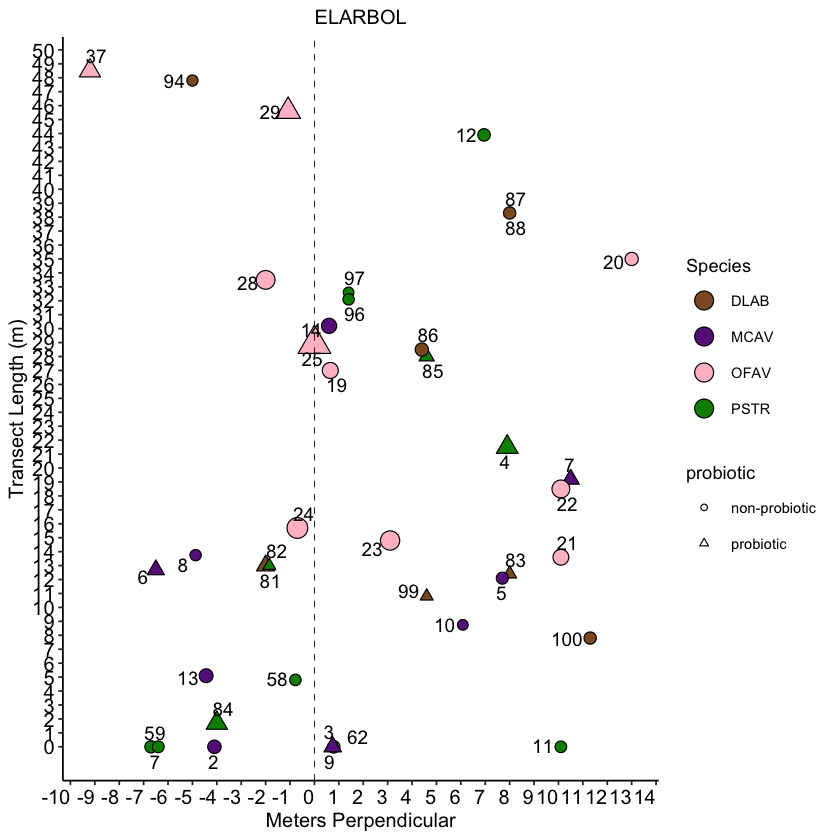

In [25]:
#tiff("ELARBOL_color.tif", width = 8, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter, shape = probiotic), color = "black") +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = ELARBOL, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 50, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-15, 15, by = 1)) +
  scale_size_continuous(range = c(2,6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  scale_shape_manual(values = c("probiotic" = 24, "non-probiotic" = 21)) +  # Assign triangle shape to probiotic
  ggtitle("ELARBOL") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
#dev.off()

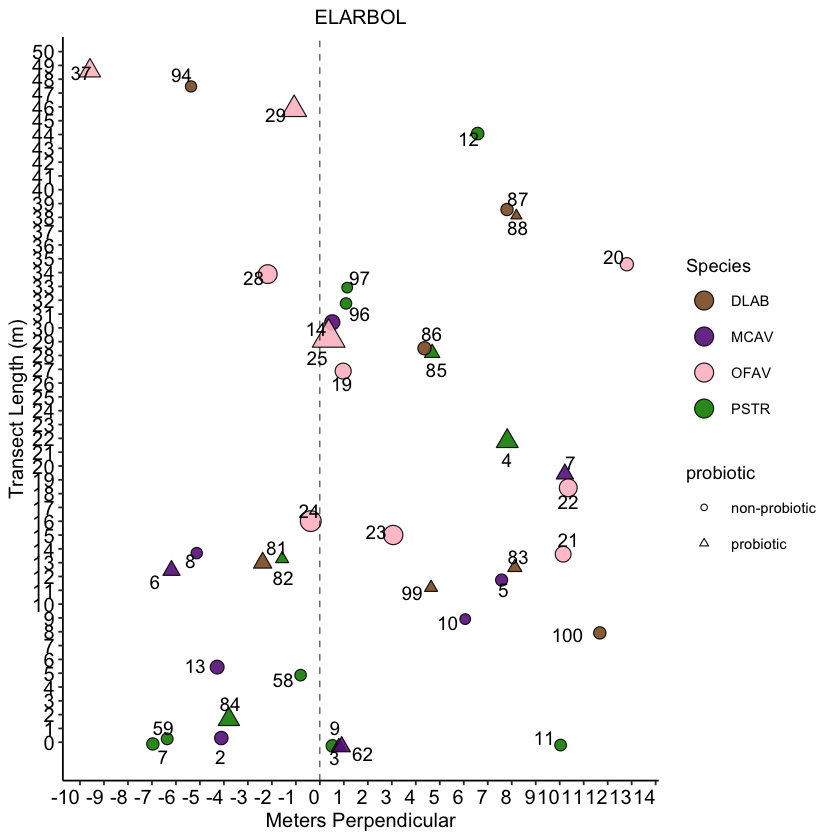

In [29]:
ggplot() +
  geom_jitter(data = ELARBOL, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter, shape = probiotic), 
              color = "black", width = 0.4, height = 0.4, alpha = 0.9) +  # Jitter to spread points
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = ELARBOL, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 50, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-15, 15, by = 1)) +
  scale_size_continuous(range = c(2,6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  scale_shape_manual(values = c("probiotic" = 24, "non-probiotic" = 21)) +  # Assign triangle shape to probiotic
  ggtitle("ELARBOL") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))


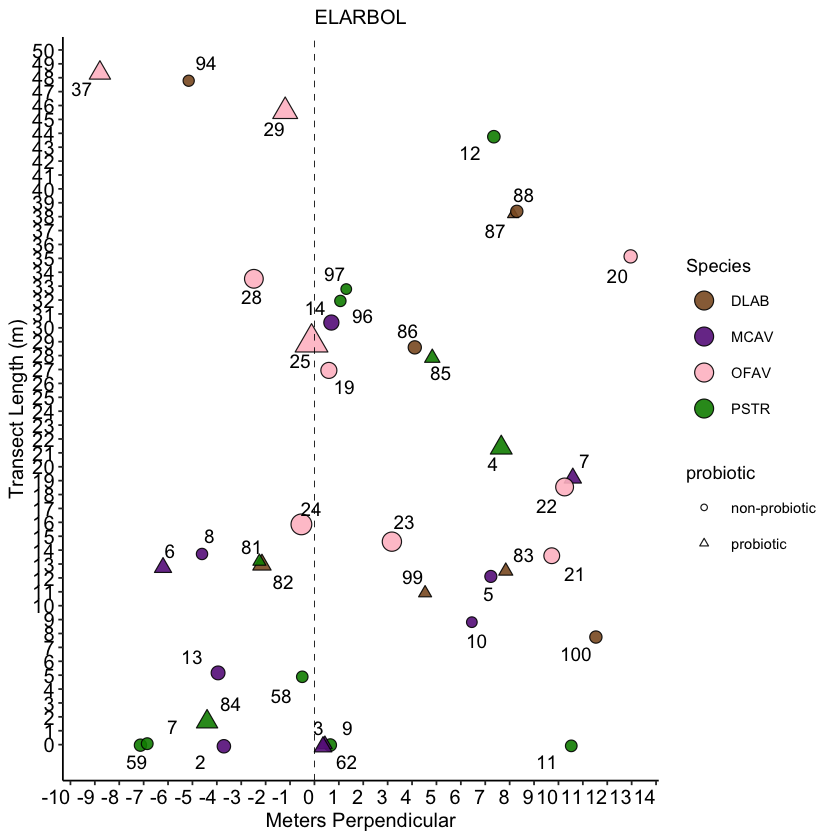

In [40]:
ggplot() +
  geom_jitter(data = ELARBOL, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter, shape = probiotic), 
              color = "black", width = 0.5, height = 0.2, alpha = 0.9) +  # Jitter to spread points
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  
  # Use geom_text_repel to avoid label overlap
  geom_text_repel(data = ELARBOL, aes(x = Meters_90, y = Meter, label = TagNum), 
                  max.overlaps = Inf,    # Allow all labels to be displayed
                  size = 4,              # Adjust label text size
                  box.padding = 0.35,    # Space around each label
                  point.padding = 0.5,   # Space between label and the point
                  segment.size = 0.2,    # Line size connecting label and point
                  segment.color = "grey50") +  # Line color
                  
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 50, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-15, 15, by = 1)) +
  scale_size_continuous(range = c(2,6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  scale_shape_manual(values = c("probiotic" = 24, "non-probiotic" = 21)) +  # Assign triangle shape to probiotic
  
  ggtitle("ELARBOL") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))

In [50]:
tiff("ELARBOL_color.tif", width = 8, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_jitter(data = ELARBOL, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter, shape = probiotic), 
              color = "black", width = 0.4, height = 0.2, alpha = 0.9) +  # Jitter to spread points
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  
  geom_point(data = ELARBOL, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  
  # Use geom_text_repel to avoid label overlap
  geom_text_repel(data = ELARBOL, aes(x = Meters_90, y = Meter, label = TagNum), 
                  max.overlaps = Inf,    # Allow all labels to be displayed
                  size = 4,              # Adjust label text size
                  box.padding = 0.35,    # Space around each label
                  point.padding = 0.5,   # Space between label and the point
                  segment.size = 0.2,    # Line size connecting label and point
                  segment.color = "grey50") +  # Line color
                  
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  
  scale_y_continuous("Transect Length (m)", breaks = seq(0, 50, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(-15, 15, by = 1)) +
  scale_size_continuous(range = c(2,6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  scale_shape_manual(values = c("probiotic" = 24, "non-probiotic" = 21)) +  # Assign triangle shape to probiotic
  
  ggtitle("ELARBOL") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

pdf 
  2

In [ ]:
getwd()

In [25]:
getwd()

[1] "/Users/brookesienkiewicz/Documents/sctld/COL2024"

## PLAZADETOROS

In [26]:
PLAZADETOROS <- corals %>% subset(Transect == "PLAZADETOROS") %>%
  subset(!(is.na(TagNum)))

In [37]:
# set max and min of y axis to longest points on the transect
max_y <- max(PLAZADETOROS$Meter)
print(max_y)
min_y <- min(PLAZADETOROS$Meter)
print(min_y)

[1] 53
[1] 1


In [38]:
# set max and min of x axis to longest points on the transect L to R
max_x <- max(PLAZADETOROS$Meters_90)
print(max_x)
min_x <- min(PLAZADETOROS$Meters_90)
print(min_x)

[1] 18
[1] -18


In [39]:
tiff("PLAZADETOROS_color.tif", width = 8, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_point(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = PLAZADETOROS, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(min_y, max_y, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(min_x, max_x, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("PLAZADETOROS") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

pdf 
  2

In [40]:
getwd()

[1] "/Users/brookesienkiewicz/Documents/sctld/COL2024"

## ROCOSA

In [42]:
ROCOSA <- corals %>% subset(Transect == "ROCOSA") %>%
  subset(!(is.na(TagNum)))

In [51]:
# set max and min of y axis to longest points on the transect
max_y <- round(max(ROCOSA$Meter))
print(max_y)
min_y <- round(min(ROCOSA$Meter))
print(min_y)

[1] 48
[1] -5


In [49]:
# set max and min of x axis to longest points on the transect L to R
max_x <- round(max(ROCOSA$Meters_90))
print(max_x)
min_x <- round(min(ROCOSA$Meters_90))
print(min_x)

[1] 10
[1] -17


In [47]:
# how to make sure scale is whole numbers??

In [52]:
tiff("ROCOSA_color.tif", width = 8, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_point(data = ROCOSA, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = ROCOSA, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = ROCOSA, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(min_y, max_y, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(min_x, max_x, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("ROCOSA") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

pdf 
  2

## Nirvana 

In [40]:
getwd()

[1] "/Users/brookesienkiewicz/Documents/sctld/COL2024"

In [54]:
NIRVANA <- corals %>% subset(Transect == "NIRVANA") %>%
  subset(!(is.na(TagNum)))

In [55]:
# set max and min of y axis to longest points on the transect
max_y <- round(max(NIRVANA$Meter))
print(max_y)
min_y <- round(min(NIRVANA$Meter))
print(min_y)

[1] 40
[1] 0


In [56]:
# set max and min of x axis to longest points on the transect L to R
max_x <- round(max(NIRVANA$Meters_90))
print(max_x)
min_x <- round(min(NIRVANA$Meters_90))
print(min_x)

[1] 10
[1] -12


In [57]:
# how to make sure scale is whole numbers??

In [58]:
tiff("NIRVANA_color.tif", width = 8, height = 10, units = "in", res = 300)
ggplot() +
  geom_point(data = NIRVANA, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = NIRVANA, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = NIRVANA, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(min_y, max_y, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(min_x, max_x, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("NIRVANA") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

pdf 
  2

In [40]:
getwd()

[1] "/Users/brookesienkiewicz/Documents/sctld/COL2024"

## PUNTAPADI

In [59]:
PUNTAPADI <- corals %>% subset(Transect == "PUNTAPADI") %>%
  subset(!(is.na(TagNum)))

In [60]:
# set max and min of y axis to longest points on the transect
max_y <- round(max(PUNTAPADI$Meter))
print(max_y)
min_y <- round(min(PUNTAPADI$Meter))
print(min_y)

[1] 39
[1] 0


In [61]:
# set max and min of x axis to longest points on the transect L to R
max_x <- round(max(PUNTAPADI$Meters_90))
print(max_x)
min_x <- round(min(PUNTAPADI$Meters_90))
print(min_x)

[1] 10
[1] -8


In [62]:
tiff("PUNTAPADI_color.tif", width = 8, height = 10, units = "in", res = 300)  # Adjust width and height
ggplot() +
  geom_point(data = PUNTAPADI, aes(x = Meters_90, y = Meter, fill = Species, size = MaxDiameter), shape = 21) +
  scale_fill_manual(values = c(speccolors), guide = guide_legend(override.aes = list(pch = 21, size = 5))) +
  geom_point(data = PUNTAPADI, aes(x = Meters_90, y = Meter, alpha = Condition), pch = 4, color = "snow", stroke = 0.5) +
  geom_vline(xintercept = 0, lty = 2, lwd = 0.25) +
  geom_text_repel(data = PUNTAPADI, aes(x = Meters_90, y = Meter, label = TagNum), max.overlaps = 20, color = "black", size = 4, hjust = -0.2) +
  scale_y_continuous("Transect Length (m)", breaks = seq(min_y, max_y, by = 1)) +
  scale_x_continuous("Meters Perpendicular", breaks = seq(min_x, max_x, by = 1)) +
  scale_size_continuous(range = c(2, 6.5), name = "", guide = 'none') +
  scale_alpha_manual(values = c(specalpha), guide = 'none') +
  ggtitle("PUNTAPADI") +
  theme(plot.title = element_text(size = 12, hjust = 0.5),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(colour = "black", hjust = 1, size = 12),
        axis.title = element_text(size = 12),
        legend.key.size = unit(1.5, "line"))
dev.off()

pdf 
  2

In [40]:
getwd()

[1] "/Users/brookesienkiewicz/Documents/sctld/COL2024"